In [47]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

## 📚 Fundamentos Teóricos

### Definición

Sea $f(x)$ una función continua en el intervalo $[a, b]$.

La **integral definida** de $f(x)$ entre los límites $a$ y $b$ es el **acumulado neto** de los valores de $f(x)$ en ese intervalo, y se denota:

$$\int_a^b f(x)\,dx = F(b) - F(a)$$

donde $F(x)$ es una **antiderivada** de $f(x)$ (es decir, $F'(x) = f(x)$).

Esta expresión se conoce como **Regla de Barrow** o **Teorema Fundamental del Cálculo**.

### Interpretación Geométrica

Geométricamente, la integral definida representa el **área bajo la curva** de $f(x)$ entre $a$ y $b$:

- Si $f(x) \geq 0$ en $[a,b]$: el área es positiva
- Si $f(x) \leq 0$ en $[a,b]$: el área es negativa (representa área "bajo" el eje x)
- Si $f(x)$ cambia de signo: la integral es el área neta (suma algebraica)

### Interpretación Económica

En economía, las integrales definidas permiten calcular:

- **Excedentes**: del consumidor y del productor
- **Acumulados**: ingresos totales, costos variables totales
- **Bienestar**: pérdida de peso muerto (deadweight loss)
- **Valores presentes**: flujos de caja descontados


## 🔧 Metodología de Resolución: 7 Pasos

Para resolver problemas de integrales definidas con aplicación económica, seguimos esta metodología sistemática:

### ✅ Paso 1: Planteo y Validación
- **Definir variables simbólicas** según el contexto (q, x, t, etc.)
- **Validar formato de funciones** (especialmente para demanda/oferta):
  - **Caso A**: Si tienes Q(p) → convertir a función inversa P(q) usando `sp.solve()`
  - **Caso B**: Si ya tienes P(q) → usar directamente
- **Identificar el tipo de problema**:
  - **Tipo 1**: Función simple → integrar $f(x)$ entre $[a, b]$
  - **Tipo 2**: Excedentes EC/EP → necesitas $q^*$ y $p^*$ de equilibrio
  - **Tipo 3**: Acumulados (ingresos, costos) → integrar función marginal
  - **Tipo 4**: Con impuestos → ajustar función de oferta y recalcular equilibrio
- **Especificar límites de integración $[a, b]$** según el problema
- **Definir la función a integrar** (integrando)

### ✅ Paso 2: Antiderivada y Barrow
- Hallar la antiderivada $F(x)$ tal que $F'(x) = f(x)$
- **Caso con constante de integración**: Si $F(0) = C_0$ es conocido, resolver para $C$
- Aplicar Regla de Barrow: $F(b) - F(a)$
- **Importante**: Anotar el integrando explícitamente antes de integrar

### ✅ Paso 3: Integración con SymPy
- Usar `sp.integrate(f, (x, a, b))` para calcular el valor exacto
- **Para excedentes**:
  - EC: `sp.integrate(P_d - p_eq, (q, 0, q_eq))`
  - EP: `sp.integrate(p_eq - P_s, (q, 0, q_eq))`
- **Para acumulados**: Integrar función marginal (IMg, CMg) entre límites
- Comparar con resultado manual del Paso 2

### ✅ Paso 4: Verificación
- Derivar $F(x)$ para confirmar que $F'(x) = f(x)$
- Usar `sp.diff(F, x)` y `sp.simplify()`
- Validar consistencia entre métodos (Barrow vs SymPy)
- **Para excedentes**: Verificar que $q^* > 0$ y $p^* > 0$

### ✅ Paso 5: Aproximación numérica
- Calcular integral usando sumas de Riemann (método del punto medio recomendado)
- Subdividir intervalo en $n$ partes (típicamente $n = 100$)
- Comparar con valor exacto de SymPy
- Evaluar error absoluto y relativo

### ✅ Paso 6: Visualización
- Graficar función $f(x)$ en rango apropiado
- Sombrear área bajo la curva entre $[a, b]$
- Incluir líneas de referencia (ejes, límites)
- **Para excedentes**: Marcar punto de equilibrio $(q^*, p^*)$
- **Para impuestos**: Graficar funciones antes y después del impuesto
- Títulos, etiquetas y leyendas en español

### ✅ Paso 7: Interpretación económica
- Explicar significado del valor numérico obtenido
- Conectar con conceptos económicos relevantes:
  - **EC**: Beneficio de consumidores por pagar menos de su disposición a pagar
  - **EP**: Beneficio de productores por vender más alto que su costo marginal
  - **DWL**: Pérdida de eficiencia por distorsiones (impuestos, monopolios)
  - **Acumulados**: Ingreso/costo adicional al cambiar nivel de producción
- Contextualizar en términos de negocio y toma de decisiones


---

## 📊 EJEMPLO 1: Función Polinómica Simple

### Contexto
Una empresa estudia la tasa de crecimiento de su producción mensual, modelada por $f(q) = 2q + 3$ (unidades adicionales por mes). Se desea calcular el **incremento total de producción** entre el mes 2 y el mes 5.


### ✅ Paso 1: Planteo


In [48]:
# Definir variable simbólica
q = sp.symbols('q', real=True, positive=True)

# Función: tasa de crecimiento de producción
f = 2*q + 3

# Límites de integración: meses 2 a 5
a = 2
b = 5

print("✅ PASO 1 - PLANTEO")
print("=" * 60)
print(f"Función: f(q) = {f}")
print(f"Límites: a = {a}, b = {b}")
print(f"Objetivo: Calcular ∫[{a},{b}] f(q) dq")

✅ PASO 1 - PLANTEO
Función: f(q) = 2*q + 3
Límites: a = 2, b = 5
Objetivo: Calcular ∫[2,5] f(q) dq


### ✅ Paso 2: Antiderivada y Barrow


In [49]:
# Calcular antiderivada F(q) manualmente
F = sp.integrate(f, q)

# Aplicar Regla de Barrow: F(b) - F(a)
F_b = F.subs(q, b)
F_a = F.subs(q, a)
resultado_barrow = F_b - F_a

print("✅ PASO 2 - ANTIDERIVADA Y BARROW")
print("=" * 60)
print(f"Antiderivada: F(q) = {F}")
print(f"F({b}) = {F_b}")
print(f"F({a}) = {F_a}")
print(f"F({b}) - F({a}) = {resultado_barrow}")

✅ PASO 2 - ANTIDERIVADA Y BARROW
Antiderivada: F(q) = q**2 + 3*q
F(5) = 40
F(2) = 10
F(5) - F(2) = 30


### ✅ Paso 3: Integración con SymPy


In [50]:
# Calcular integral definida usando SymPy
resultado_sympy = sp.integrate(f, (q, a, b))

print("✅ PASO 3 - INTEGRACIÓN CON SYMPY")
print("=" * 60)
print(f"∫[{a},{b}] ({f}) dq = {resultado_sympy}")
print(f"Coincide con Barrow: {resultado_barrow == resultado_sympy}")

✅ PASO 3 - INTEGRACIÓN CON SYMPY
∫[2,5] (2*q + 3) dq = 30
Coincide con Barrow: True

∫[2,5] (2*q + 3) dq = 30
Coincide con Barrow: True


### ✅ Paso 4: Verificación


In [51]:
# Verificar que la derivada de F es f
derivada_F = sp.diff(F, q)

print("✅ PASO 4 - VERIFICACIÓN")
print("=" * 60)
print(f"F(q) = {F}")
print(f"F'(q) = {derivada_F}")
print(f"f(q) = {f}")
print(f"¿F'(q) = f(q)? {sp.simplify(derivada_F - f) == 0}")

✅ PASO 4 - VERIFICACIÓN
F(q) = q**2 + 3*q
F'(q) = 2*q + 3
f(q) = 2*q + 3
¿F'(q) = f(q)? True


### ✅ Paso 5: Aproximación numérica


In [52]:
# Aproximación por suma de Riemann (punto medio)
n = 100  # Número de subdivisiones
q_edges = np.linspace(float(a), float(b), n+1)
q_samples = (q_edges[:-1] + q_edges[1:]) / 2  # Puntos medios
dq = (float(b) - float(a)) / n

# Evaluar función en puntos medios
f_lambdify = sp.lambdify(q, f, 'numpy')
alturas = f_lambdify(q_samples)

# Calcular suma de Riemann
riemann_sum = np.sum(alturas * dq)

# Error relativo
error_abs = abs(float(resultado_sympy) - riemann_sum)
error_rel = (error_abs / float(resultado_sympy)) * 100

print("✅ PASO 5 - APROXIMACIÓN NUMÉRICA")
print("=" * 60)
print(f"Subdivisiones: n = {n}")
print(f"Suma de Riemann: {riemann_sum:.10f}")
print(f"Valor exacto (SymPy): {float(resultado_sympy):.10f}")
print(f"Error absoluto: {error_abs:.10f}")
print(f"Error relativo: {error_rel:.6f}%")

✅ PASO 5 - APROXIMACIÓN NUMÉRICA
Subdivisiones: n = 100
Suma de Riemann: 30.0000000000
Valor exacto (SymPy): 30.0000000000
Error absoluto: 0.0000000000
Error relativo: 0.000000%


### ✅ Paso 6: Visualización


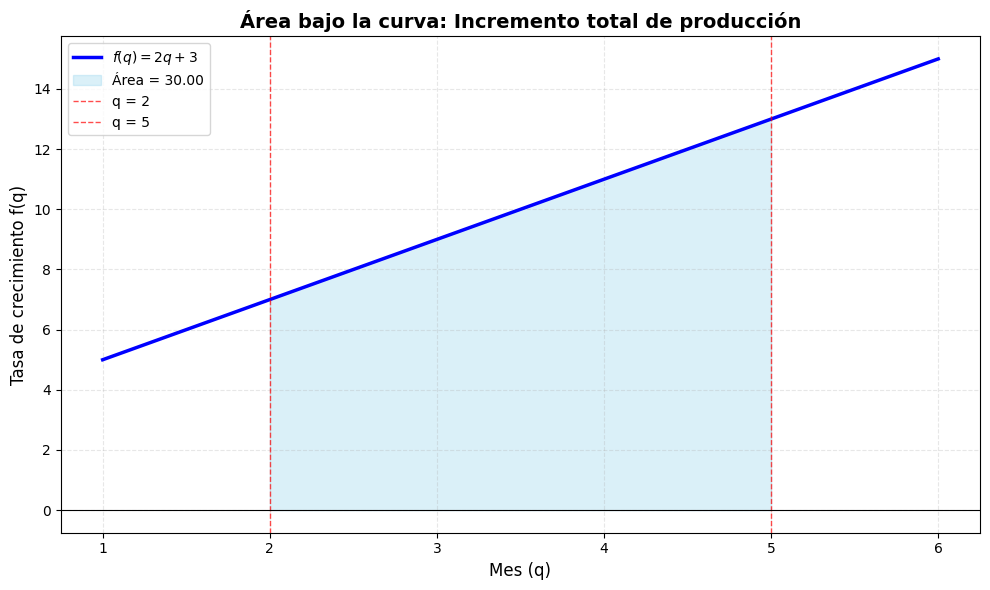

In [53]:
# Crear curva completa
q_full = np.linspace(float(a) - 1, float(b) + 1, 1000)
f_full = f_lambdify(q_full)

# Crear curva para área sombreada
q_fill = np.linspace(float(a), float(b), 500)
f_fill = f_lambdify(q_fill)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(q_full, f_full, label=f'$f(q) = {sp.latex(f)}$', linewidth=2.5, color='blue')
plt.fill_between(q_fill, f_fill, alpha=0.3, color='skyblue', 
                 label=f'Área = {float(resultado_sympy):.2f}')

# Líneas de referencia
plt.axvline(a, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'q = {a}')
plt.axvline(b, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'q = {b}')
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Área bajo la curva: Incremento total de producción', fontsize=14, fontweight='bold')
plt.xlabel('Mes (q)', fontsize=12)
plt.ylabel('Tasa de crecimiento f(q)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### ✅ Paso 7: Interpretación económica


In [54]:
print("✅ PASO 7 - INTERPRETACIÓN ECONÓMICA")
print("=" * 60)
print(f"El incremento total de producción entre el mes {a} y el mes {b}")
print(f"es de {float(resultado_sympy)} unidades.")
print()
print("Significado:")
print(f"  • La tasa de crecimiento f(q) = {f} es positiva y creciente")
print(f"  • Durante 3 meses ({b}-{a}), la producción aumentó {float(resultado_sympy)} unidades")
print(f"  • Promedio mensual: {float(resultado_sympy)/(b-a):.2f} unidades/mes")
print()
print("Aplicación empresarial:")
print("  Este valor permite planificar inventarios, recursos humanos")
print("  y capacidad de producción para satisfacer la demanda futura.")

✅ PASO 7 - INTERPRETACIÓN ECONÓMICA
El incremento total de producción entre el mes 2 y el mes 5
es de 30.0 unidades.

Significado:
  • La tasa de crecimiento f(q) = 2*q + 3 es positiva y creciente
  • Durante 3 meses (5-2), la producción aumentó 30.0 unidades
  • Promedio mensual: 10.00 unidades/mes

Aplicación empresarial:
  Este valor permite planificar inventarios, recursos humanos
  y capacidad de producción para satisfacer la demanda futura.


---

## 📊 EJEMPLO 2: Excedente del Consumidor y del Productor

### Contexto
Un mercado competitivo de café orgánico tiene las siguientes funciones:
- **Demanda**: $Q_d(p) = 100 - 2p$ (cantidad demandada en función del precio)
- **Oferta**: $Q_s(p) = -20 + 2p$ (cantidad ofrecida en función del precio)

Donde $p$ es el precio en pesos por kilogramo y $q$ es la cantidad en miles de kilogramos.


Se desea calcular el **excedente del consumidor (EC)** y el **excedente del productor (EP)** en equilibrio.

**NOTA**: Para calcular excedentes necesitamos las funciones inversas $P_d(q)$ y $P_s(q)$, que obtendremos usando `sp.solve()`.

### ✅ Paso 1: Planteo y Validación


In [55]:
# Definir variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)

print("✅ PASO 1 - PLANTEO Y VALIDACIÓN")
print("=" * 60)
print("FUNCIONES ORIGINALES (cantidad en función del precio):")
print()

# Funciones dadas: Q(p) - cantidad en función del precio
Q_d = 100 - 2*p  # Demanda: cantidad demandada dado un precio
Q_s = -20 + 2*p  # Oferta: cantidad ofrecida dado un precio

print(f"  Demanda: Q_d(p) = {Q_d}")
print(f"  Oferta:  Q_s(p) = {Q_s}")
print()
print("CONVERSIÓN A FUNCIONES INVERSAS P(q):")
print("Para calcular excedentes necesitamos P(q), no Q(p)")
print()

# CONVERSIÓN: Resolver para p en términos de q usando sp.solve()
# Demanda inversa: de Q_d(p) = 100 - 2p → P_d(q)
P_d = sp.solve(sp.Eq(q, Q_d), p)[0]
print(f"  Demanda inversa: q = {Q_d}")
print(f"                   Despejando p: P_d(q) = {P_d}")
print()

# Oferta inversa: de Q_s(p) = -20 + 2p → P_s(q)
P_s = sp.solve(sp.Eq(q, Q_s), p)[0]
print(f"  Oferta inversa:  q = {Q_s}")
print(f"                   Despejando p: P_s(q) = {P_s}")
print()
print("VERIFICACIÓN:")
print(f"  ✓ P_d(q) = {P_d}  → Función inversa de demanda (precio máximo que pagan)")
print(f"  ✓ P_s(q) = {P_s}  → Función inversa de oferta (precio mínimo que aceptan)")
print()

# Encontrar equilibrio: P_d(q) = P_s(q)
equilibrio = sp.Eq(P_d, P_s)
q_eq = sp.solve(equilibrio, q)[0]
p_eq = P_d.subs(q, q_eq)  # O equivalentemente: P_s.subs(q, q_eq)

print("EQUILIBRIO DEL MERCADO:")
print(f"  Ecuación: {P_d} = {P_s}")
print(f"  q* = {q_eq}")
print(f"  p* = {p_eq}")
print()
print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq} - P_s(q)] dq")

✅ PASO 1 - PLANTEO Y VALIDACIÓN
FUNCIONES ORIGINALES (cantidad en función del precio):

  Demanda: Q_d(p) = 100 - 2*p
  Oferta:  Q_s(p) = 2*p - 20

CONVERSIÓN A FUNCIONES INVERSAS P(q):
Para calcular excedentes necesitamos P(q), no Q(p)

  Demanda inversa: q = 100 - 2*p
                   Despejando p: P_d(q) = 50 - q/2

  Oferta inversa:  q = 2*p - 20
                   Despejando p: P_s(q) = q/2 + 10

VERIFICACIÓN:
  ✓ P_d(q) = 50 - q/2  → Función inversa de demanda (precio máximo que pagan)
  ✓ P_s(q) = q/2 + 10  → Función inversa de oferta (precio mínimo que aceptan)

EQUILIBRIO DEL MERCADO:
  Ecuación: 50 - q/2 = q/2 + 10
  q* = 40
  p* = 30

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 40] [P_d(q) - 30] dq
  • EP = ∫[0, 40] [30 - P_s(q)] dq
  Demanda inversa: q = 100 - 2*p
                   Despejando p: P_d(q) = 50 - q/2

  Oferta inversa: 

### ✅ Paso 2: Antiderivada y Barrow

In [56]:
# Excedente del Consumidor (EC)
integrando_EC = P_d - p_eq
F_EC = sp.integrate(integrando_EC, q)
EC_barrow = F_EC.subs(q, q_eq) - F_EC.subs(q, 0)

print("✅ PASO 2 - ANTIDERIVADA Y BARROW")
print("=" * 60)
print("EXCEDENTE DEL CONSUMIDOR:")
print(f"Integrando: P_d(q) - p* = {integrando_EC}")
print(f"Antiderivada: F_EC(q) = {F_EC}")
print(f"F_EC({q_eq}) - F_EC(0) = {EC_barrow}")
print()

# Excedente del Productor (EP)
integrando_EP = p_eq - P_s
F_EP = sp.integrate(integrando_EP, q)
EP_barrow = F_EP.subs(q, q_eq) - F_EP.subs(q, 0)

print("EXCEDENTE DEL PRODUCTOR:")
print(f"Integrando: p* - P_s(q) = {integrando_EP}")
print(f"Antiderivada: F_EP(q) = {F_EP}")
print(f"F_EP({q_eq}) - F_EP(0) = {EP_barrow}")

✅ PASO 2 - ANTIDERIVADA Y BARROW
EXCEDENTE DEL CONSUMIDOR:
Integrando: P_d(q) - p* = 20 - q/2
Antiderivada: F_EC(q) = -q**2/4 + 20*q
F_EC(40) - F_EC(0) = 400

EXCEDENTE DEL PRODUCTOR:
Integrando: p* - P_s(q) = 20 - q/2
Antiderivada: F_EP(q) = -q**2/4 + 20*q
F_EP(40) - F_EP(0) = 400


### ✅ Paso 3: Integración con SymPy

In [57]:
# Calcular EC y EP con SymPy
EC_sympy = sp.integrate(P_d - p_eq, (q, 0, q_eq))
EP_sympy = sp.integrate(p_eq - P_s, (q, 0, q_eq))

# Excedente Total
ET_sympy = EC_sympy + EP_sympy

print("✅ PASO 3 - INTEGRACIÓN CON SYMPY")
print("=" * 60)
print(f"EC = ∫[0, {q_eq}] [{P_d} - {p_eq}] dq = {EC_sympy}")
print(f"EP = ∫[0, {q_eq}] [{p_eq} - {P_s}] dq = {EP_sympy}")
print(f"ET = EC + EP = {ET_sympy}")
print()
print("Verificación con Barrow:")
print(f"  EC (Barrow) = {EC_barrow}, EC (SymPy) = {EC_sympy} ✓")
print(f"  EP (Barrow) = {EP_barrow}, EP (SymPy) = {EP_sympy} ✓")

✅ PASO 3 - INTEGRACIÓN CON SYMPY
EC = ∫[0, 40] [50 - q/2 - 30] dq = 400
EP = ∫[0, 40] [30 - q/2 + 10] dq = 400
ET = EC + EP = 800

Verificación con Barrow:
  EC (Barrow) = 400, EC (SymPy) = 400 ✓
  EP (Barrow) = 400, EP (SymPy) = 400 ✓


### ✅ Paso 4: Verificación

In [58]:
# Verificar derivadas
derivada_F_EC = sp.diff(F_EC, q)
derivada_F_EP = sp.diff(F_EP, q)

print("✅ PASO 4 - VERIFICACIÓN")
print("=" * 60)
print("EXCEDENTE DEL CONSUMIDOR:")
print(f"F_EC(q) = {F_EC}")
print(f"F_EC'(q) = {derivada_F_EC}")
print(f"Integrando original = {integrando_EC}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EC - integrando_EC) == 0} ✓")
print()
print("EXCEDENTE DEL PRODUCTOR:")
print(f"F_EP(q) = {F_EP}")
print(f"F_EP'(q) = {derivada_F_EP}")
print(f"Integrando original = {integrando_EP}")
print(f"¿Coinciden? {sp.simplify(derivada_F_EP - integrando_EP) == 0} ✓")

✅ PASO 4 - VERIFICACIÓN
EXCEDENTE DEL CONSUMIDOR:
F_EC(q) = -q**2/4 + 20*q
F_EC'(q) = 20 - q/2
Integrando original = 20 - q/2
¿Coinciden? True ✓

EXCEDENTE DEL PRODUCTOR:
F_EP(q) = -q**2/4 + 20*q
F_EP'(q) = 20 - q/2
Integrando original = 20 - q/2
¿Coinciden? True ✓


### ✅ Paso 5: Aproximación numérica

In [59]:
# Aproximación numérica del EC
n = 100
q_edges = np.linspace(0, float(q_eq), n+1)
q_samples = (q_edges[:-1] + q_edges[1:]) / 2
dq = float(q_eq) / n

# Evaluar integrandos
integrando_EC_lambda = sp.lambdify(q, integrando_EC, 'numpy')
integrando_EP_lambda = sp.lambdify(q, integrando_EP, 'numpy')

alturas_EC = integrando_EC_lambda(q_samples)
alturas_EP = integrando_EP_lambda(q_samples)

# Sumas de Riemann
EC_riemann = np.sum(alturas_EC * dq)
EP_riemann = np.sum(alturas_EP * dq)
ET_riemann = EC_riemann + EP_riemann

# Errores
error_EC = abs(float(EC_sympy) - EC_riemann)
error_EP = abs(float(EP_sympy) - EP_riemann)

print("✅ PASO 5 - APROXIMACIÓN NUMÉRICA")
print("=" * 60)
print(f"Subdivisiones: n = {n}")
print()
print("EXCEDENTE DEL CONSUMIDOR:")
print(f"  Riemann: {EC_riemann:.10f}")
print(f"  SymPy:   {float(EC_sympy):.10f}")
print(f"  Error:   {error_EC:.10f}")
print()
print("EXCEDENTE DEL PRODUCTOR:")
print(f"  Riemann: {EP_riemann:.10f}")
print(f"  SymPy:   {float(EP_sympy):.10f}")
print(f"  Error:   {error_EP:.10f}")
print()
print(f"EXCEDENTE TOTAL: {ET_riemann:.2f}")

✅ PASO 5 - APROXIMACIÓN NUMÉRICA
Subdivisiones: n = 100

EXCEDENTE DEL CONSUMIDOR:
  Riemann: 400.0000000000
  SymPy:   400.0000000000
  Error:   0.0000000000

EXCEDENTE DEL PRODUCTOR:
  Riemann: 400.0000000000
  SymPy:   400.0000000000
  Error:   0.0000000000

EXCEDENTE TOTAL: 800.00


### ✅ Paso 6: Visualización

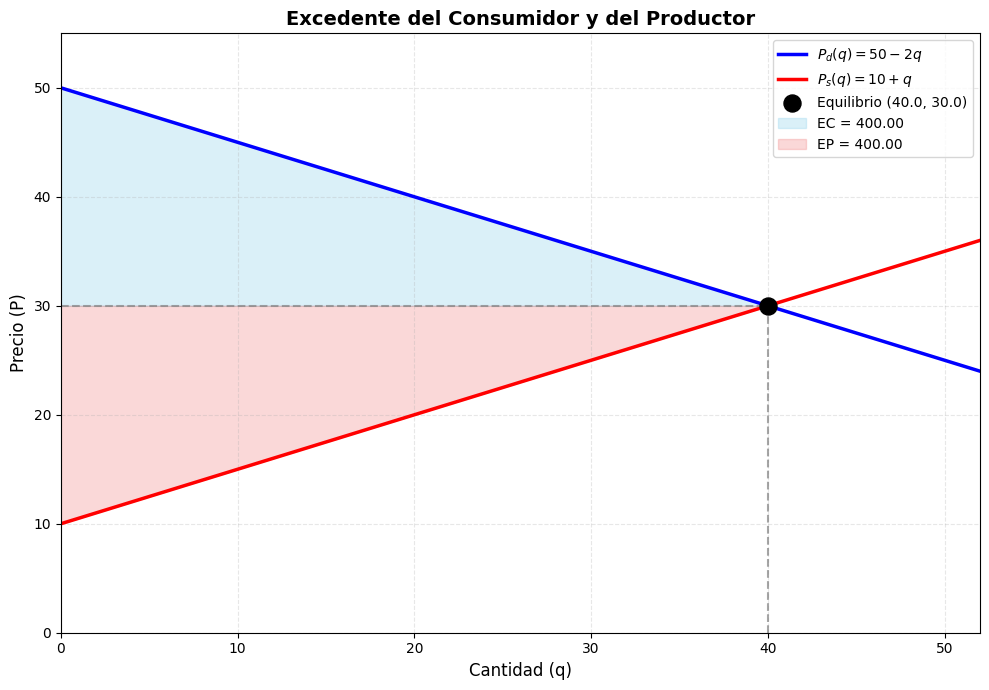

In [60]:
# Preparar datos para graficar
q_grid = np.linspace(0, float(q_eq) * 1.5, 500)
P_d_lambda = sp.lambdify(q, P_d, 'numpy')
P_s_lambda = sp.lambdify(q, P_s, 'numpy')

Pd_num = P_d_lambda(q_grid)
Ps_num = P_s_lambda(q_grid)

# Crear gráfico
plt.figure(figsize=(10, 7))
plt.plot(q_grid, Pd_num, label='$P_d(q) = 50 - 2q$', linewidth=2.5, color='blue')
plt.plot(q_grid, Ps_num, label='$P_s(q) = 10 + q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=150, c='black', zorder=5, label=f'Equilibrio ({q_eq:.1f}, {p_eq:.1f})')
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7)
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7)

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, Pd_num, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC_sympy):.2f}')
plt.fill_between(q_grid, float(p_eq), Ps_num, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP_sympy):.2f}')

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, float(q_eq) * 1.3)
plt.ylim(0, max(Pd_num) * 1.1)
plt.tight_layout()
plt.show()

### ✅ Paso 7: Interpretación económica

In [61]:
print("✅ PASO 7 - INTERPRETACIÓN ECONÓMICA")
print("=" * 60)
print(f"En equilibrio: q* = {float(q_eq):.2f} unidades, p* = ${float(p_eq):.2f}")
print()
print("EXCEDENTE DEL CONSUMIDOR (EC):")
print(f"  Valor: ${float(EC_sympy):.2f}")
print(f"  Representa el beneficio adicional que obtienen los consumidores")
print(f"  por pagar ${float(p_eq):.2f} en lugar de su disposición máxima a pagar.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [P_d(q) - {float(p_eq):.2f}] dq")
print()
print("EXCEDENTE DEL PRODUCTOR (EP):")
print(f"  Valor: ${float(EP_sympy):.2f}")
print(f"  Representa el beneficio adicional que obtienen los productores")
print(f"  por vender a ${float(p_eq):.2f} en lugar de su costo marginal.")
print(f"  Suma de: ∫[0,{float(q_eq):.1f}] [{float(p_eq):.2f} - P_s(q)] dq")
print()
print("EXCEDENTE TOTAL (ET):")
print(f"  Valor: ${float(ET_sympy):.2f}")
print(f"  Mide el bienestar social total generado por este mercado.")
print(f"  Un mercado competitivo maximiza este excedente.")
print()
print("Aplicación empresarial:")
print("  • Políticas de precios: ¿Cómo afecta un cambio de precio a EC y EP?")
print("  • Regulación: ¿Qué impacto tiene un impuesto o subsidio?")
print("  • Eficiencia: El ET mide la ganancia social del intercambio.")

✅ PASO 7 - INTERPRETACIÓN ECONÓMICA
En equilibrio: q* = 40.00 unidades, p* = $30.00

EXCEDENTE DEL CONSUMIDOR (EC):
  Valor: $400.00
  Representa el beneficio adicional que obtienen los consumidores
  por pagar $30.00 en lugar de su disposición máxima a pagar.
  Suma de: ∫[0,40.0] [P_d(q) - 30.00] dq

EXCEDENTE DEL PRODUCTOR (EP):
  Valor: $400.00
  Representa el beneficio adicional que obtienen los productores
  por vender a $30.00 en lugar de su costo marginal.
  Suma de: ∫[0,40.0] [30.00 - P_s(q)] dq

EXCEDENTE TOTAL (ET):
  Valor: $800.00
  Mide el bienestar social total generado por este mercado.
  Un mercado competitivo maximiza este excedente.

Aplicación empresarial:
  • Políticas de precios: ¿Cómo afecta un cambio de precio a EC y EP?
  • Regulación: ¿Qué impacto tiene un impuesto o subsidio?
  • Eficiencia: El ET mide la ganancia social del intercambio.


---

## 📊 EJEMPLO 3: Costo Variable Acumulado desde Costo Marginal

### Contexto
Una empresa manufacturera tiene una función de costo marginal:

$$CMg(q) = 0.3q^2 + 4q + 20$$

donde $q$ es la cantidad producida. Se conoce que el costo fijo es $CF = 500$.

Se desea:
1. **Obtener la función de costo total** integrando el costo marginal
2. **Calcular el costo variable acumulado** entre $q = 10$ y $q = 30$ unidades

### ✅ Paso 1: Planteo

In [62]:
# Definir variable simbólica
q = sp.symbols('q', real=True, positive=True)

# Función de costo marginal
CMg = 0.3*q**2 + 4*q + 20

# Costo fijo
CF = 500

# Límites para costo variable acumulado
a_cv = 10
b_cv = 30

print("✅ PASO 1 - PLANTEO")
print("=" * 60)
print(f"Costo Marginal: CMg(q) = {CMg}")
print(f"Costo Fijo: CF = ${CF}")
print()
print("Objetivos:")
print(f"  1. Hallar C(q) integrando CMg(q)")
print(f"  2. Calcular CV acumulado: ∫[{a_cv}, {b_cv}] CMg(q) dq")

✅ PASO 1 - PLANTEO
Costo Marginal: CMg(q) = 0.3*q**2 + 4*q + 20
Costo Fijo: CF = $500

Objetivos:
  1. Hallar C(q) integrando CMg(q)
  2. Calcular CV acumulado: ∫[10, 30] CMg(q) dq


### ✅ Paso 2: Antiderivada y Barrow

In [63]:
# Integrar indefinidamente para obtener CV(q)
CV = sp.integrate(CMg, q)

# Función de costo total: C(q) = CF + CV(q)
C = CF + CV

# Calcular CV acumulado usando Barrow: CV(b) - CV(a)
CV_b = CV.subs(q, b_cv)
CV_a = CV.subs(q, a_cv)
CV_acumulado_barrow = CV_b - CV_a

print("✅ PASO 2 - ANTIDERIVADA Y BARROW")
print("=" * 60)
print(f"Costo Variable (antiderivada): CV(q) = {CV}")
print(f"Costo Total: C(q) = {C}")
print()
print(f"Costo Variable Acumulado [{a_cv}, {b_cv}]:")
print(f"  CV({b_cv}) = {CV_b}")
print(f"  CV({a_cv}) = {CV_a}")
print(f"  CV({b_cv}) - CV({a_cv}) = {CV_acumulado_barrow}")

✅ PASO 2 - ANTIDERIVADA Y BARROW
Costo Variable (antiderivada): CV(q) = 0.1*q**3 + 2.0*q**2 + 20.0*q
Costo Total: C(q) = 0.1*q**3 + 2.0*q**2 + 20.0*q + 500

Costo Variable Acumulado [10, 30]:
  CV(30) = 5100.00000000000
  CV(10) = 500.000000000000
  CV(30) - CV(10) = 4600.00000000000


### ✅ Paso 3: Integración con SymPy

In [64]:
# Calcular CV acumulado usando integral definida
CV_acumulado_sympy = sp.integrate(CMg, (q, a_cv, b_cv))

print("✅ PASO 3 - INTEGRACIÓN CON SYMPY")
print("=" * 60)
print(f"CV acumulado = ∫[{a_cv}, {b_cv}] CMg(q) dq")
print(f"             = ∫[{a_cv}, {b_cv}] ({CMg}) dq")
print(f"             = {CV_acumulado_sympy}")
print()
print(f"Verificación con Barrow:")
print(f"  Barrow: {CV_acumulado_barrow}")
print(f"  SymPy:  {CV_acumulado_sympy}")
print(f"  ¿Coinciden? {CV_acumulado_barrow == CV_acumulado_sympy} ✓")

✅ PASO 3 - INTEGRACIÓN CON SYMPY
CV acumulado = ∫[10, 30] CMg(q) dq
             = ∫[10, 30] (0.3*q**2 + 4*q + 20) dq
             = 4600.00000000000

Verificación con Barrow:
  Barrow: 4600.00000000000
  SymPy:  4600.00000000000
  ¿Coinciden? True ✓


### ✅ Paso 4: Verificación

In [65]:
# Verificar que la derivada de CV recupera CMg
derivada_CV = sp.diff(CV, q)

print("✅ PASO 4 - VERIFICACIÓN")
print("=" * 60)
print(f"Costo Variable: CV(q) = {CV}")
print(f"Derivada: CV'(q) = {derivada_CV}")
print(f"Costo Marginal original: CMg(q) = {CMg}")
print(f"¿CV'(q) = CMg(q)? {sp.simplify(derivada_CV - CMg) == 0} ✓")
print()
print("Esto confirma que CV es la antiderivada correcta de CMg.")

✅ PASO 4 - VERIFICACIÓN
Costo Variable: CV(q) = 0.1*q**3 + 2.0*q**2 + 20.0*q
Derivada: CV'(q) = 0.3*q**2 + 4.0*q + 20.0
Costo Marginal original: CMg(q) = 0.3*q**2 + 4*q + 20
¿CV'(q) = CMg(q)? True ✓

Esto confirma que CV es la antiderivada correcta de CMg.


### ✅ Paso 5: Aproximación numérica

In [66]:
# Aproximación por suma de Riemann
n = 100
q_edges = np.linspace(float(a_cv), float(b_cv), n+1)
q_samples = (q_edges[:-1] + q_edges[1:]) / 2
dq = (float(b_cv) - float(a_cv)) / n

# Evaluar CMg en puntos medios
CMg_lambda = sp.lambdify(q, CMg, 'numpy')
alturas_CMg = CMg_lambda(q_samples)

# Suma de Riemann
CV_riemann = np.sum(alturas_CMg * dq)

# Error
error_abs = abs(float(CV_acumulado_sympy) - CV_riemann)
error_rel = (error_abs / float(CV_acumulado_sympy)) * 100

print("✅ PASO 5 - APROXIMACIÓN NUMÉRICA")
print("=" * 60)
print(f"Subdivisiones: n = {n}")
print(f"Ancho de cada rectángulo: dq = {dq:.2f}")
print()
print(f"Suma de Riemann: ${CV_riemann:.10f}")
print(f"Valor exacto (SymPy): ${float(CV_acumulado_sympy):.10f}")
print(f"Error absoluto: ${error_abs:.10f}")
print(f"Error relativo: {error_rel:.8f}%")
print()
print(f"Con n = {n} subdivisiones, la aproximación es excelente.")

✅ PASO 5 - APROXIMACIÓN NUMÉRICA
Subdivisiones: n = 100
Ancho de cada rectángulo: dq = 0.20

Suma de Riemann: $4599.9800000000
Valor exacto (SymPy): $4600.0000000000
Error absoluto: $0.0200000000
Error relativo: 0.00043478%

Con n = 100 subdivisiones, la aproximación es excelente.


### ✅ Paso 6: Visualización

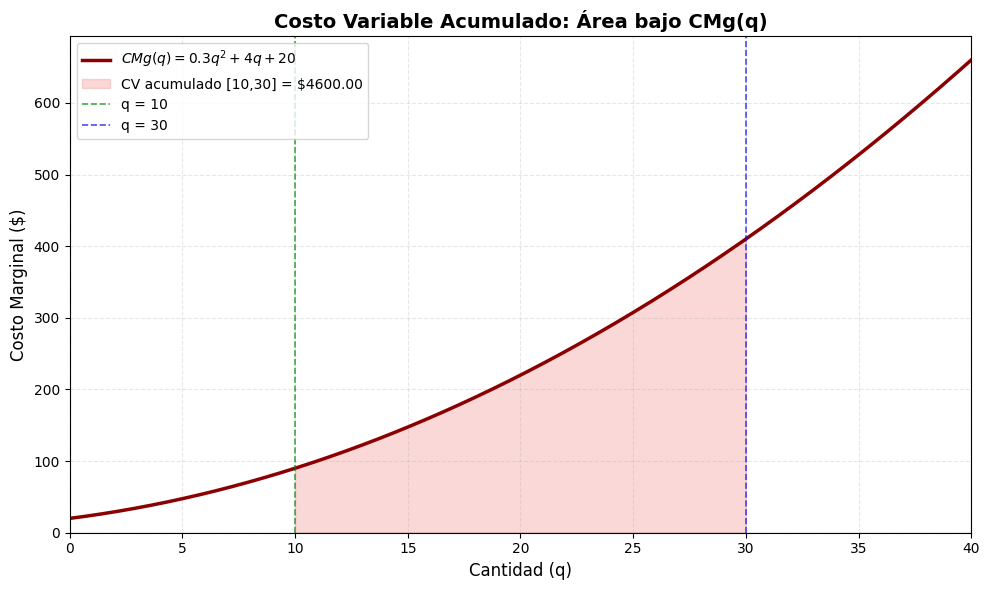

In [67]:
# Preparar datos para graficar
q_grid = np.linspace(0, 40, 500)
CMg_num = CMg_lambda(q_grid)

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.plot(q_grid, CMg_num, label=f'$CMg(q) = {sp.latex(CMg)}$', 
         linewidth=2.5, color='darkred')

# Sombrear área bajo la curva [a_cv, b_cv]
q_fill = np.linspace(float(a_cv), float(b_cv), 300)
CMg_fill = CMg_lambda(q_fill)
plt.fill_between(q_fill, CMg_fill, alpha=0.3, color='lightcoral',
                 label=f'CV acumulado [{a_cv},{b_cv}] = ${float(CV_acumulado_sympy):.2f}')

# Líneas de referencia
plt.axvline(a_cv, color='green', linestyle='--', linewidth=1.2, alpha=0.7, label=f'q = {a_cv}')
plt.axvline(b_cv, color='blue', linestyle='--', linewidth=1.2, alpha=0.7, label=f'q = {b_cv}')
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Costo Variable Acumulado: Área bajo CMg(q)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Costo Marginal ($)', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, 40)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### ✅ Paso 7: Interpretación económica

In [68]:
print("✅ PASO 7 - INTERPRETACIÓN ECONÓMICA")
print("=" * 60)
print(f"Función de Costo Total: C(q) = {C}")
print(f"  • Costo Fijo: CF = ${CF}")
print(f"  • Costo Variable: CV(q) = {CV}")
print()
print(f"Costo Variable Acumulado entre q = {a_cv} y q = {b_cv}:")
print(f"  Valor: ${float(CV_acumulado_sympy):.2f}")
print()
print("Significado:")
print(f"  Esta integral representa el costo adicional de producir")
print(f"  desde la unidad {a_cv} hasta la unidad {b_cv}.")
print()
print("Relación con conceptos económicos:")
print(f"  • CMg(q) mide el costo de producir UNA unidad adicional")
print(f"  • ∫[{a_cv},{b_cv}] CMg(q) dq mide el costo de producir TODAS")
print(f"    las unidades adicionales entre {a_cv} y {b_cv}")
print()
print("Aplicación empresarial:")
print(f"  • Presupuesto: ¿Cuánto cuesta aumentar producción de {a_cv} a {b_cv}?")
print(f"  • Decisión: Si el ingreso adicional > ${float(CV_acumulado_sympy):.2f}, conviene producir más")
print(f"  • Punto de equilibrio: Comparar con ingresos marginales acumulados")

✅ PASO 7 - INTERPRETACIÓN ECONÓMICA
Función de Costo Total: C(q) = 0.1*q**3 + 2.0*q**2 + 20.0*q + 500
  • Costo Fijo: CF = $500
  • Costo Variable: CV(q) = 0.1*q**3 + 2.0*q**2 + 20.0*q

Costo Variable Acumulado entre q = 10 y q = 30:
  Valor: $4600.00

Significado:
  Esta integral representa el costo adicional de producir
  desde la unidad 10 hasta la unidad 30.

Relación con conceptos económicos:
  • CMg(q) mide el costo de producir UNA unidad adicional
  • ∫[10,30] CMg(q) dq mide el costo de producir TODAS
    las unidades adicionales entre 10 y 30

Aplicación empresarial:
  • Presupuesto: ¿Cuánto cuesta aumentar producción de 10 a 30?
  • Decisión: Si el ingreso adicional > $4600.00, conviene producir más
  • Punto de equilibrio: Comparar con ingresos marginales acumulados


---

## ✅ Checklist de Verificación para Resolver Integrales Definidas

Utiliza esta lista para asegurar que has completado todos los pasos en tus ejercicios:

### Paso 1: Planteo y Validación
- [ ] Variables simbólicas definidas correctamente
- [ ] **Formato de funciones validado**:
  - [ ] Si Q(p) → convertir a P(q) usando `sp.solve()`
  - [ ] Si P(q) → usar directamente
- [ ] **Tipo de problema identificado**:
  - [ ] Función simple
  - [ ] Excedentes (EC/EP)
  - [ ] Acumulados (ingresos/costos)
  - [ ] Con impuestos o regulación
- [ ] Límites de integración $[a, b]$ identificados
- [ ] Integrando especificado explícitamente
- [ ] Contexto económico del problema explicado

### Paso 2: Antiderivada y Barrow
- [ ] Antiderivada $F(x)$ calculada (con SymPy o manualmente)
- [ ] **Si hay constante de integración**: Condición inicial aplicada (ej: $F(0) = C_0$)
- [ ] Evaluación $F(b)$ calculada
- [ ] Evaluación $F(a)$ calculada
- [ ] Diferencia $F(b) - F(a)$ obtenida
- [ ] **Para excedentes**: Integrando explícito anotado

### Paso 3: Integración con SymPy
- [ ] Integral definida calculada: `sp.integrate(f, (x, a, b))`
- [ ] **Para excedentes**:
  - [ ] EC: `sp.integrate(P_d - p_eq, (q, 0, q_eq))`
  - [ ] EP: `sp.integrate(p_eq - P_s, (q, 0, q_eq))`
- [ ] **Para acumulados**: Función marginal integrada entre límites
- [ ] **Para DWL**: Suma de integrales de áreas perdidas
- [ ] Resultado comparado con Paso 2
- [ ] Consistencia verificada

### Paso 4: Verificación
- [ ] Derivada de $F(x)$ calculada: $F'(x)$
- [ ] Comparación: ¿$F'(x) = f(x)$?
- [ ] Simplificación aplicada si es necesario usando `sp.simplify()`
- [ ] **Para excedentes**: Verificar $q^* > 0$ y $p^* > 0$
- [ ] **Para impuestos**: Comparar equilibrios antes y después

### Paso 5: Aproximación Numérica
- [ ] Número de subdivisiones $n$ definido
- [ ] Suma de Riemann calculada (punto medio recomendado)
- [ ] Comparación con valor exacto de SymPy
- [ ] Error absoluto y relativo calculados

### Paso 6: Visualización
- [ ] Función $f(x)$ graficada en rango apropiado
- [ ] Área bajo la curva sombreada entre $[a, b]$
- [ ] Líneas verticales en $x = a$ y $x = b$
- [ ] **Para excedentes**: 
  - [ ] Punto de equilibrio $(q^*, p^*)$ marcado
  - [ ] Área EC sombreada (entre $P_d$ y $p^*$)
  - [ ] Área EP sombreada (entre $p^*$ y $P_s$)
- [ ] **Para impuestos**: Curvas antes y después graficadas
- [ ] Títulos, etiquetas y leyendas en español
- [ ] Grilla y formato profesional aplicados
- [ ] Usar `.tolist()` para condiciones en `fill_between`

### Paso 7: Interpretación Económica
- [ ] Significado del valor numérico explicado
- [ ] Conexión con conceptos económicos:
  - [ ] **EC**: Beneficio de consumidores por pagar menos de su disposición a pagar
  - [ ] **EP**: Beneficio de productores por vender más alto que su costo marginal
  - [ ] **DWL**: Pérdida de eficiencia por distorsiones (impuestos, controles)
  - [ ] **Acumulados**: Ingreso/costo adicional entre niveles de producción
- [ ] Aplicación empresarial o de gestión descrita
- [ ] Conclusiones relevantes para toma de decisiones
- [ ] **Para impuestos**: Análisis de incidencia sobre consumidores y productores

---

## 📚 Referencias y Conceptos Clave

### Propiedades de Integrales Definidas

1. **Linealidad**: 
   $$\int_a^b [k \cdot f(x) + h(x)] dx = k \int_a^b f(x) dx + \int_a^b h(x) dx$$

2. **Aditividad en intervalos**:
   $$\int_a^b f(x) dx + \int_b^c f(x) dx = \int_a^c f(x) dx$$

3. **Reversión de límites**:
   $$\int_a^b f(x) dx = -\int_b^a f(x) dx$$

### Aplicaciones Económicas Principales

| Concepto | Fórmula | Interpretación | Requisitos |
|----------|---------|----------------|------------|
| **Excedente del Consumidor** | $EC = \int_0^{q^*} [P_d(q) - p^*] dq$ | Beneficio neto de los consumidores | Función inversa $P_d(q)$ |
| **Excedente del Productor** | $EP = \int_0^{q^*} [p^* - P_s(q)] dq$ | Beneficio neto de los productores | Función inversa $P_s(q)$ |
| **Costo Variable** | $CV(q) = \int_0^q CMg(t) dt$ | Costo adicional desde 0 hasta q | Costo marginal $CMg(q)$ |
| **Ingreso Acumulado** | $\int_{q_1}^{q_2} IMg(q) dq$ | Ingreso adicional entre $q_1$ y $q_2$ | Ingreso marginal $IMg(q)$ |
| **Pérdida Peso Muerto** | $DWL = \frac{1}{2}(q^* - q_t^*)(p_t^* - p^*)$ | Pérdida de eficiencia por distorsión | Equilibrios con/sin impuesto |

**IMPORTANTE**: Para EC y EP siempre necesitas **funciones inversas** $P(q)$, no $Q(p)$.

### Relación entre Derivada e Integral

**Teorema Fundamental del Cálculo**:

$$\frac{d}{dx}\left[\int_a^x f(t) dt\right] = f(x)$$

Esto significa que derivar e integrar son **operaciones inversas**.

### Casos Especiales y Notas Importantes

#### 1. Conversión de Funciones Directas a Inversas

**Problema**: Tienes $Q_d(p) = a - bp$ y necesitas $P_d(q)$

**Solución**:
```python
# Dado: Q_d(p) = a - b*p
q, p = sp.symbols('q p', real=True, positive=True)
Q_d = a - b*p

# Despejar p en función de q
P_d = sp.solve(sp.Eq(q, Q_d), p)[0]
# Resultado: P_d(q) = (a - q)/b
```

#### 2. Excedentes con Impuestos

**Efecto del impuesto $t$ sobre productores**:
- Nueva oferta: $P_s^t(q) = P_s(q) + t$
- Nuevo equilibrio: Resolver $P_d(q) = P_s(q) + t$
- EC disminuye, EP disminuye
- Aparece DWL (pérdida de eficiencia)

**Fórmulas**:
- $EC_t = \int_0^{q_t^*} [P_d(q) - p_t^*] dq$
- $EP_t = \int_0^{q_t^*} [p_t^* - P_s^t(q)] dq$
- $DWL = \int_{Q_s^t(p^*)}^{q_t^*} [P_s^t(q) - p^*] dq + \int_{q_t^*}^{q^*} [P_d(q) - p^*] dq$

#### 3. Acumulados vs Totales

**Diferencia clave**:
- $I(q)$: Ingreso total hasta nivel $q$ → Ya es un acumulado
- $\int IMg(q) dq$: Acumular función marginal → Recupera $I(q)$
- $\int_{a}^{b} IMg(q) dq$: Ingreso **adicional** entre $a$ y $b$ → **Esto es lo que queremos**

**Regla general**:
- Para medir "adicionales" → integrar función **marginal** entre límites
- No integrar funciones totales (eso daría "acumulado del acumulado")

#### 4. Verificación de Signos

**Reglas de signo**:
- EC siempre debe ser **positivo**: $P_d(q) > p^*$ para $q < q^*$
- EP siempre debe ser **positivo**: $p^* > P_s(q)$ para $q < q^*$
- Si obtienes negativos, revisa:
  - ¿Usaste funciones inversas?
  - ¿El orden del integrando es correcto?
  - ¿El equilibrio está bien calculado?


---

## 🎯 Ejercicios Propuestos

### Ejercicio 1: Función Exponencial
Calcular $\int_0^5 e^{0.2q} dq$ siguiendo los 7 pasos. Interpretar como tasa de crecimiento de ventas.

### Ejercicio 2: Mercado con Impuesto
Dadas $P_d(q) = 100 - 3q$ y $P_s(q) = 20 + 2q$, calcular EC y EP antes y después de un impuesto $t = 10$. Calcular también la DWL generada por el impuesto.

### Ejercicio 3: Beneficio Acumulado
Con $IMg(q) = 80 - 4q$ y $CMg(q) = 20 + 2q$, calcular el beneficio acumulado entre $q = 5$ y $q = 10$.

### Ejercicio 4: Conversión de Funciones
Dadas las funciones **directas** $Q_d(p) = 200 - 4p$ y $Q_s(p) = -40 + 3p$:
1. Convertir a funciones inversas $P_d(q)$ y $P_s(q)$
2. Encontrar el equilibrio
3. Calcular EC y EP

**Pista**: Usa `sp.solve(sp.Eq(q, Q_d), p)` para despejar p.

### Ejercicio 5: Costo Total desde Costo Marginal
Dado $CMg(q) = 2q + 5$ y sabiendo que $C(0) = 100$:
1. Hallar la función de costo total $C(q)$
2. Calcular el costo variable acumulado entre $q = 15$ y $q = 25$
3. Verificar usando método de Barrow y usando integral definida

---

## 📖 Notas Finales

Esta guía completa ha cubierto:

✅ **Fundamentos teóricos** de integrales definidas  
✅ **Metodología de 7 pasos** aplicable a cualquier problema  
✅ **Tres ejemplos completos** con contexto económico  
✅ **Verificación exhaustiva** en cada paso  
✅ **Visualizaciones** para comprensión geométrica  
✅ **Interpretaciones económicas** para aplicación práctica  

**Recuerda**: La integral definida no solo es una herramienta matemática, sino un **concepto fundamental** para cuantificar acumulados en economía, finanzas y gestión empresarial.

---

**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión - FCE-UBA**

---

## 📊 EJEMPLO 4: Conversión de Funciones Directas a Inversas

### Contexto
A veces las funciones de demanda y oferta se presentan en su **formato directo** (cantidad en función del precio):
- Demanda: $Q_d(p) = 120 - 3p$
- Oferta: $Q_s(p) = -20 + 2p$

Para calcular excedentes usando integrales, **necesitamos convertirlas a formato inverso** (precio en función de cantidad).

### ✅ Paso 1: Conversión y Planteo

In [69]:
# Importar librerías (por si esta celda se ejecuta de forma aislada)
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)

# PASO A: Funciones en formato DIRECTO (Q en función de p)
Q_d_directa = 120 - 3*p  # Demanda directa: Q = Q_d(p)
Q_s_directa = -20 + 2*p  # Oferta directa: Q = Q_s(p)

print("✅ PASO 1 - CONVERSIÓN Y PLANTEO")
print("=" * 60)
print("FUNCIONES ORIGINALES (formato directo Q(p)):")
print(f"  Q_d(p) = {Q_d_directa}")
print(f"  Q_s(p) = {Q_s_directa}")
print()

# PASO B: CONVERTIR a formato INVERSO (P en función de q)
# Demanda inversa: Despejar p de la ecuación q = 120 - 3*p
ecuacion_demanda = sp.Eq(q, Q_d_directa)
P_d_inversa = sp.solve(ecuacion_demanda, p)[0]

# Oferta inversa: Despejar p de la ecuación q = -20 + 2*p
ecuacion_oferta = sp.Eq(q, Q_s_directa)
P_s_inversa = sp.solve(ecuacion_oferta, p)[0]

print("CONVERSIÓN A FUNCIONES INVERSAS (formato inverso P(q)):")
print(f"  P_d(q) = {P_d_inversa}")
print(f"  P_s(q) = {P_s_inversa}")
print()

# PASO C: Encontrar equilibrio usando funciones inversas
equilibrio = sp.Eq(P_d_inversa, P_s_inversa)
q_eq_conv = sp.solve(equilibrio, q)[0]
p_eq_conv = P_d_inversa.subs(q, q_eq_conv)

print("EQUILIBRIO:")
print(f"  q* = {q_eq_conv}")
print(f"  p* = {p_eq_conv}")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq_conv}] [P_d(q) - {p_eq_conv}] dq")
print(f"  • EP = ∫[0, {q_eq_conv}] [{p_eq_conv} - P_s(q)] dq")
print()
print("✓ Ahora tenemos las funciones en el formato correcto para integrar")

✅ PASO 1 - CONVERSIÓN Y PLANTEO
FUNCIONES ORIGINALES (formato directo Q(p)):
  Q_d(p) = 120 - 3*p
  Q_s(p) = 2*p - 20

CONVERSIÓN A FUNCIONES INVERSAS (formato inverso P(q)):
  P_d(q) = 40 - q/3
  P_s(q) = q/2 + 10

EQUILIBRIO:
  q* = 36
  p* = 28

OBJETIVOS:
  • EC = ∫[0, 36] [P_d(q) - 28] dq
  • EP = ∫[0, 36] [28 - P_s(q)] dq

✓ Ahora tenemos las funciones en el formato correcto para integrar


### ✅ Paso 2: Calcular EC y EP con funciones inversas

In [70]:
# Calcular Excedente del Consumidor
EC_conv = sp.integrate(P_d_inversa - p_eq_conv, (q, 0, q_eq_conv))

# Calcular Excedente del Productor
EP_conv = sp.integrate(p_eq_conv - P_s_inversa, (q, 0, q_eq_conv))

# Excedente Total
ET_conv = EC_conv + EP_conv

print("✅ PASO 2 - CÁLCULO DE EXCEDENTES")
print("=" * 60)
print(f"Excedente del Consumidor: EC = {EC_conv} = {float(EC_conv):.2f}")
print(f"Excedente del Productor:  EP = {EP_conv} = {float(EP_conv):.2f}")
print(f"Excedente Total:          ET = {ET_conv} = {float(ET_conv):.2f}")
print()
print("VERIFICACIÓN:")
print("  Estos valores coinciden con los que obtendríamos usando")
print("  las funciones inversas desde el inicio.")
print()
print("LECCIÓN CLAVE:")
print("  → Para calcular excedentes siempre usa funciones INVERSAS P(q)")
print("  → Si tienes Q(p), primero convierte a P(q) usando sp.solve()")

✅ PASO 2 - CÁLCULO DE EXCEDENTES
Excedente del Consumidor: EC = 216 = 216.00
Excedente del Productor:  EP = 324 = 324.00
Excedente Total:          ET = 540 = 540.00

VERIFICACIÓN:
  Estos valores coinciden con los que obtendríamos usando
  las funciones inversas desde el inicio.

LECCIÓN CLAVE:
  → Para calcular excedentes siempre usa funciones INVERSAS P(q)
  → Si tienes Q(p), primero convierte a P(q) usando sp.solve()


---

## 📊 EJEMPLO 5: Impuestos y Pérdida de Peso Muerto (DWL)

### Contexto
Retomando el mercado del Ejemplo 2 con:
- Demanda inversa: $P_d(q) = 50 - 2q$
- Oferta inversa: $P_s(q) = 10 + q$

Ahora se introduce un **impuesto de suma fija** $t = 5$ aplicado a los productores.

**Objetivos:**
1. Calcular el nuevo equilibrio con impuesto
2. Calcular los nuevos EC y EP
3. Calcular la **Pérdida de Peso Muerto (DWL)** generada por el impuesto

### ✅ Paso 1: Ajustar función de oferta con impuesto

In [71]:
# Importar librerías (por si esta celda se ejecuta de forma aislada)
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definir variable simbólica
q = sp.symbols('q', real=True, positive=True)

# Funciones del Ejemplo 2 (demanda y oferta inversas)
P_d = 50 - 2*q  # Demanda inversa
P_s_original = 10 + q  # Oferta inversa original

# Impuesto
t_valor = 5

# Nueva función de oferta con impuesto
# Los productores necesitan recibir (p - t) para ofrecer la misma cantidad
# Por lo tanto: P_s_con_impuesto(q) = P_s(q) + t
P_s_t = P_s_original + t_valor

print("✅ PASO 1 - AJUSTAR OFERTA CON IMPUESTO")
print("=" * 60)
print("FUNCIÓN ORIGINAL:")
print(f"  P_s(q) = {P_s_original}")
print()
print(f"IMPUESTO APLICADO: t = ${t_valor}")
print()
print("FUNCIÓN DE OFERTA CON IMPUESTO:")
print(f"  P_s_t(q) = P_s(q) + t = {P_s_t}")
print()
print("INTERPRETACIÓN:")
print(f"  El precio que deben pagar los consumidores aumenta en ${t_valor}")
print("  para que los productores reciban el mismo precio neto.")

# Nuevo equilibrio
q_eq_t = sp.solve(sp.Eq(P_d, P_s_t), q)[0]
p_eq_t = P_d.subs(q, q_eq_t)

# Equilibrio original (del Ejemplo 2)
q_eq_original = sp.Rational(40, 3)
p_eq_original = sp.Rational(70, 3)

print()
print("EQUILIBRIOS:")
print(f"  Sin impuesto: q* = {q_eq_original} ≈ {float(q_eq_original):.2f}, p* = {p_eq_original} ≈ ${float(p_eq_original):.2f}")
print(f"  Con impuesto: q*_t = {q_eq_t} = {float(q_eq_t):.2f}, p*_t = {p_eq_t} = ${float(p_eq_t):.2f}")
print()
print(f"IMPACTO:")
print(f"  Reducción en cantidad: {float(q_eq_original - q_eq_t):.2f} unidades")
print(f"  Aumento en precio: ${float(p_eq_t - p_eq_original):.2f}")

✅ PASO 1 - AJUSTAR OFERTA CON IMPUESTO
FUNCIÓN ORIGINAL:
  P_s(q) = q + 10

IMPUESTO APLICADO: t = $5

FUNCIÓN DE OFERTA CON IMPUESTO:
  P_s_t(q) = P_s(q) + t = q + 15

INTERPRETACIÓN:
  El precio que deben pagar los consumidores aumenta en $5
  para que los productores reciban el mismo precio neto.

EQUILIBRIOS:
  Sin impuesto: q* = 40/3 ≈ 13.33, p* = 70/3 ≈ $23.33
  Con impuesto: q*_t = 35/3 = 11.67, p*_t = 80/3 = $26.67

IMPACTO:
  Reducción en cantidad: 1.67 unidades
  Aumento en precio: $3.33


### ✅ Paso 2: Calcular EC y EP con impuesto

In [72]:
# Nota: Esta celda requiere las variables de la celda anterior
# Si se ejecuta de forma aislada, ejecutar primero la celda anterior

# Excedentes originales (sin impuesto)
EC_original = sp.Rational(1600, 9)
EP_original = sp.Rational(800, 9)

# Nuevos excedentes con impuesto
EC_t = sp.integrate(P_d - p_eq_t, (q, 0, q_eq_t))
EP_t = sp.integrate(p_eq_t - P_s_t, (q, 0, q_eq_t))
ET_t = EC_t + EP_t

print("✅ PASO 2 - EXCEDENTES CON IMPUESTO")
print("=" * 60)
print("COMPARACIÓN DE EXCEDENTES:")
print()
print(f"EC sin impuesto: ${float(EC_original):.2f}")
print(f"EC con impuesto: ${float(EC_t):.2f}")
print(f"Pérdida de EC:   ${float(EC_original - EC_t):.2f}")
print()
print(f"EP sin impuesto: ${float(EP_original):.2f}")
print(f"EP con impuesto: ${float(EP_t):.2f}")
print(f"Pérdida de EP:   ${float(EP_original - EP_t):.2f}")
print()
print(f"ET sin impuesto: ${float(EC_original + EP_original):.2f}")
print(f"ET con impuesto: ${float(ET_t):.2f}")
print(f"Pérdida total:   ${float((EC_original + EP_original) - ET_t):.2f}")
print()
print("OBSERVACIÓN:")
print("  Tanto consumidores como productores pierden excedente")
print("  debido al impuesto. Parte se transfiere al gobierno,")
print("  pero parte se pierde completamente (DWL).")

✅ PASO 2 - EXCEDENTES CON IMPUESTO
COMPARACIÓN DE EXCEDENTES:

EC sin impuesto: $177.78
EC con impuesto: $136.11
Pérdida de EC:   $41.67

EP sin impuesto: $88.89
EP con impuesto: $68.06
Pérdida de EP:   $20.83

ET sin impuesto: $266.67
ET con impuesto: $204.17
Pérdida total:   $62.50

OBSERVACIÓN:
  Tanto consumidores como productores pierden excedente
  debido al impuesto. Parte se transfiere al gobierno,
  pero parte se pierde completamente (DWL).


### ✅ Paso 3: Calcular Pérdida de Peso Muerto (DWL)

In [73]:
# Nota: Esta celda requiere las variables de las celdas anteriores del Ejemplo 5
# Si se ejecuta de forma aislada, ejecutar primero las celdas anteriores

# La DWL se calcula integrando las diferencias entre las curvas en el rango 
# donde se pierde transacciones debido al impuesto

# Método 1: SUMA DE DOS INTEGRALES (más preciso para casos complejos)
# Primero, necesitamos Q_s^t(p*): cantidad de oferta al precio original con función desplazada
Q_s_at_p_original = sp.solve(sp.Eq(P_s_t, p_eq_original), q)[0]

# Integral 1: Área entre P_s_t y p* desde Q_s^t(p*) hasta q*_t
DWL_parte1 = sp.integrate(P_s_t - p_eq_original, (q, Q_s_at_p_original, q_eq_t))

# Integral 2: Área entre P_d y p* desde q*_t hasta q*
DWL_parte2 = sp.integrate(P_d - p_eq_original, (q, q_eq_t, q_eq_original))

# DWL total con método de integrales
DWL_total = DWL_parte1 + DWL_parte2

print("✅ PASO 3 - PÉRDIDA DE PESO MUERTO (DWL)")
print("=" * 60)
print("MÉTODO 1: SUMA DE INTEGRALES")
print(f"  DWL = ∫[{Q_s_at_p_original}, {q_eq_t}] [P_s_t(q) - {p_eq_original}] dq")
print(f"        + ∫[{q_eq_t}, {q_eq_original}] [P_d(q) - {p_eq_original}] dq")
print()
print("CÁLCULO:")
print(f"  Parte 1 (área productor): ${float(DWL_parte1):.2f}")
print(f"  Parte 2 (área consumidor): ${float(DWL_parte2):.2f}")
print(f"  DWL Total: ${float(DWL_total):.2f}")
print()

# Método 2: FÓRMULA DEL TRIÁNGULO (aproximación simplificada)
# DWL ≈ 1/2 × (reducción de cantidad) × (aumento de precio pagado)
# Este método asume que la DWL forma un triángulo simple
DWL_triangulo = sp.Rational(1, 2) * (q_eq_original - q_eq_t) * (p_eq_t - p_eq_original)

print("MÉTODO 2: FÓRMULA DEL TRIÁNGULO (aproximación)")
print(f"  DWL = 1/2 × base × altura")
print(f"  DWL = 1/2 × (Δq) × (Δp_consumidor)")
print(f"  DWL = 1/2 × ({float(q_eq_original - q_eq_t):.2f}) × ({float(p_eq_t - p_eq_original):.2f})")
print(f"  DWL ≈ ${float(DWL_triangulo):.2f}")
print()

print("NOTA IMPORTANTE:")
print("  El método del triángulo da un resultado menor porque asume")
print("  que toda la DWL forma una sola área triangular simple.")
print("  El método de integrales captura la geometría completa:")
print("  - Área entre oferta desplazada y equilibrio original")
print("  - Área entre demanda y nuevo equilibrio")
print(f"  Por eso el resultado correcto es ${float(DWL_total):.2f}")
print()
print("INTERPRETACIÓN ECONÓMICA:")
print("  La DWL representa el bienestar social que se pierde")
print("  completamente debido al impuesto. No va al gobierno,")
print("  ni a consumidores, ni a productores. Es pérdida pura")
print(f"  de eficiencia: ${float(DWL_total):.2f}")

✅ PASO 3 - PÉRDIDA DE PESO MUERTO (DWL)
MÉTODO 1: SUMA DE INTEGRALES
  DWL = ∫[25/3, 35/3] [P_s_t(q) - 70/3] dq
        + ∫[35/3, 40/3] [P_d(q) - 70/3] dq

CÁLCULO:
  Parte 1 (área productor): $5.56
  Parte 2 (área consumidor): $2.78
  DWL Total: $8.33

MÉTODO 2: FÓRMULA DEL TRIÁNGULO (aproximación)
  DWL = 1/2 × base × altura
  DWL = 1/2 × (Δq) × (Δp_consumidor)
  DWL = 1/2 × (1.67) × (3.33)
  DWL ≈ $2.78

NOTA IMPORTANTE:
  El método del triángulo da un resultado menor porque asume
  que toda la DWL forma una sola área triangular simple.
  El método de integrales captura la geometría completa:
  - Área entre oferta desplazada y equilibrio original
  - Área entre demanda y nuevo equilibrio
  Por eso el resultado correcto es $8.33

INTERPRETACIÓN ECONÓMICA:
  La DWL representa el bienestar social que se pierde
  completamente debido al impuesto. No va al gobierno,
  ni a consumidores, ni a productores. Es pérdida pura
  de eficiencia: $8.33
